In [1]:
# Importing needed code

from pathlib import Path
from typing import Callable, Literal

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier, bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.signal import savgol_filter

# Load Data

In [2]:
# Location of PSD data folder; change as needed
PARQ_ROOT = Path("C:/Users/User/Desktop/FOM Analysis/UBC Background 20221214-19/psd")

In [3]:
# Load PSD data to "psd_report" DataFrame
psd_report = pd.read_parquet(PARQ_ROOT, columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
psd_report = psd_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

# Calculate PSD value as new column "tail / total"
psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report = psd_report.dropna()
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
psd_report.head()

,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total
0,0.140062,156,196,16418502401,0.204082
1,0.195247,222,275,24318455424,0.192727
2,0.391638,467,556,26788604245,0.160072
3,1.107950,1335,1579,35113666523,0.154528
4,0.103046,123,143,55876842932,0.139860


In [4]:
# Generate random sample of "psd_report" for graphing
# Graphing 300M points is way too slow, so best to graph a reasonable fraction of all points

sample_frac = 0.1  # fraction of points to put in sample (0-1)
random_state = 1323  # random number generator seed; change to try different samples

graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

In [5]:
# Define plotting variables

fontsize = 24
label_size = 22

In [6]:
# Graph PSD vs Energy scatterplot

# fig, ax = plt.subplots(figsize=(12,12))

# ax.scatter(
#     graph_sample["CALIB_ENERGY"], graph_sample["tail / total"], s=0.5, alpha=0.8
# )

# ax.set_ylabel("PSD", fontsize=fontsize)
# ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
# ax.set_title("PSD vs Energy", fontsize=fontsize)
# ax.tick_params(axis='both', which='major', labelsize=label_size)
# ax.tick_params(axis='both', which='minor', labelsize=label_size)

## Heatmap & Histograms

In [7]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

resolution = int(1024/2)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

In [8]:
# Find energy slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0056 MeVee'

In [9]:
# Graph heatmap of 2D histogram

# fig, ax = plt.subplots(figsize=(8,8))
# cmap = plt.colormaps["nipy_spectral"]
# pcm = ax.pcolormesh(xe, ye, Z.T, cmap=cmap)

# fontsize = 24
# ax.set_xlim(xe[0],1.5)
# ax.set_title("Heatmap of Counts", fontsize=fontsize)
# ax.set_ylabel("PSD", fontsize=fontsize)
# ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
# ax.tick_params(axis='both', which='major', labelsize=22)
# ax.tick_params(axis='both', which='minor', labelsize=22)
# fig.colorbar(pcm, ax=ax)

In [10]:
# Graph 2D histogram as 3D contour plot (like a geographic height map)
# Allows view of the entire dataset's "shape"

# contour_res = 60  # number of contour lines to use
# angle_elev = 55  # Elevation angle (-90=underneath, 0=side, 90=above)
# angle_rot = 0  # Rotation angle (0=down X (energy) axis, + rotates clockwise)
# log_mode = True  # Graph dataset using log counts (useful for small neutron counts)

# fig = plt.figure(figsize=(12,12))
# ax = plt.axes(projection='3d')

# x, y = np.meshgrid(xe[:-1], ye[:-1])

# ax.view_init(angle_elev, angle_rot)
# if log_mode:
#     ax.contour3D(x, y, np.log10(Z.T+1), contour_res, cmap=cmap)
# else:
#     ax.contour3D(x, y, Z.T, contour_res, cmap=cmap)

# # ax.plot_surface(x, y, Z.T, cmap=cmap, antialiased=True)
# # ax.zaxis.set_major_locator(ticker.LogLocator())

# # ax.contour([0.35, 0.35], [0, 0], [100, 100])
# ax.set_title("PSD Histogram", fontsize=16)
# ax.set_ylabel("PSD", fontsize=16)
# ax.set_xlabel("Energy (MeVee)", fontsize=16)
# ax.set_zlabel("Log Counts", fontsize=16)
# # ax.set_zticklabels(range(0,1000))
# # ax.vlines(0.35, 0, 100)
# # ax.set_zscale("log")
# # ax.set_zlim(0,10**3)

# FOM Analysis

In [11]:
# FOM function definition

BimodalParams = tuple[float, float, float, float, float, float]
GaussianParams = tuple[float, float, float]
BimodalBounds = tuple[BimodalParams, BimodalParams]

def split_params(
    params: BimodalParams
) -> tuple[GaussianParams, GaussianParams]:
    """Separates bimodal function parameters into 2 sets, one per component gaussian
    
    Parameters
    ----------
    params: BimodalParams
        parameters of a bimodal function
        
    Returns
    -------
    lower_gaussian_params: GaussianParams
        parameters of the lower gaussian (i.e. lower mu value)
    upper_gaussian_params: GaussianParams
        parameters of the upper gaussian (i.e. higher mu value)
    """
    params = abs(params)
    return params[0:3], params[3:]

def get_bimodal_fit(
    bins: np.ndarray, 
    histogram_slice: np.ndarray, 
    bounds: BimodalBounds
) -> tuple[GaussianParams, GaussianParams, np.ndarray]:
    """Fits a histogram slice to a bimodal distribution
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram_slice: ndarray
        slice of the 2D PSD/Energy histogram taken for a specific energy (i.e. PSD vs Counts)
    bounds: BimodalBounds
        lower and upper bounds of fit parameters for this slice
        
    Returns
    -------
    gamma_params: GaussianParams
        parameters of the gaussian fit for gamma rays
    neutron_params: GaussianParams
        parameters of the gaussian fit for neutrons
    cov: ndarray
        estimated covariance of all bimodial parameters
    """
    params, cov = curve_fit(
        bimodal,
        bins,
        histogram_slice,
        bounds=bounds,
    )
    
    gamma_params, neutron_params = split_params(params)
    
    return gamma_params, neutron_params, cov


def scan_histogram_slices(
    bins: np.ndarray, 
    histogram: np.ndarray, 
    default_bounds: BimodalBounds,
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None = None, 
    start_idx: int = 0, 
    end_idx: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Determines bimodal fit and FOM for every energy slice in 2D PSD/Energy histogram
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram: ndarray
        2D PSD/Energy histogram
    default_bounds: BimodalBounds
        default lower and upper bounds of fit parameters
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None, default None
        allows custom bounds for slice ranges. 
        Each list entry must have a tuple of start and stop indexes, and corresponding fit bounds.
        Bounds are used when the slice index falls within the start/stop range (start inclusive, stop exclusive).
        If index ranges overlap, the last matching range is used.
        If bounds is None, only default_bounds are used.
    start_idx: int, default 0
        starting index (inclusive) of slice range to fit to bimodal
    end_idx: int | None, default None
        ending index (exclusive) of slice range to fit to bimodal
        
    Returns
    -------
    fit_dataframe: DataFrame
        DataFrame of fit parameters including FOM (as columns) for each slice (as rows)
    error_dataframe: DataFrame
        DataFrame of (1 standard deviation) errors in fit parameters (as columns) for each slice (as rows)
    """
    end_idx = len(histogram) if end_idx is None else min(len(histogram), end_idx)
        
    slice_params = []
    slice_err = []
    
    for i in range(start_idx, end_idx):
        fit_bounds = default_bounds
        
        if bounds is not None :
            for i_range, bound in bounds:
                if i in range(*i_range):
                    fit_bounds = bound
        
#         print(f"default = {default_bounds}\nbounds={bounds}")
        gamma_params, neutron_params, cov = get_bimodal_fit(bins, histogram[:,i], fit_bounds)
        
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        
        perr = np.sqrt(np.diag(cov))
    
        slice_params.append((i, *gamma_params, *neutron_params, fom))
        slice_err.append((i, *perr))
    
    columns = ['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2']
    df = pd.DataFrame(slice_params, columns=columns + ['fom'])
    err_df = pd.DataFrame(slice_err, columns=columns)
    
    return df, err_df

In [12]:
# Scan 2D histogram's energy slices and get bimodal fit

psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

start_scan_idx = 0
end_scan_idx = 420

end_scan_idx = min(end_scan_idx, len(Z))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)


df.head()

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.165886,0.010000,1.000000,0.350000,0.04,7.720373e-01,1.563720
1,1,0.149992,0.010000,1.000000,0.352909,0.01,9.677842e-05,4.308532
2,2,0.149992,0.010000,1.000000,0.352908,0.01,4.838911e-05,4.308522
3,3,0.121636,0.010000,1.000000,0.352909,0.01,1.802631e-13,4.910621
4,4,0.100000,0.099996,9.268862,0.359951,0.01,1.624592e-15,1.003593


In [13]:
# Find energy slices with FOM between 1.2 and 1.3 (energy cutoff area of interest)

fom_slice = df.query("(1.2 < fom) & (fom <= 1.3)")
fom_slice

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
7,7,0.100000,0.081925,52.186548,0.36,0.01,0.067552,1.201113
28,28,0.157058,0.027751,6015.503332,0.35,0.04,9.885388,1.209346
29,29,0.156905,0.027228,5853.077988,0.35,0.04,9.116566,1.219731
30,30,0.156905,0.026701,5714.003577,0.35,0.04,8.812703,1.229375
31,31,0.156671,0.026208,5588.700324,0.35,0.04,8.476408,1.240027
32,32,0.156626,0.025647,5471.916151,0.35,0.04,8.472932,1.250917
33,33,0.156395,0.025330,5319.776893,0.35,0.04,8.329967,1.258474
34,34,0.156236,0.024932,5188.674993,0.35,0.04,7.889314,1.267234
35,35,0.156128,0.024547,5080.183535,0.35,0.04,7.935844,1.275507
36,36,0.156044,0.024144,4983.478868,0.35,0.04,8.178977,1.284069


In [14]:
# Manually find FOM threshold slice (number is index of first slice past threshold)

fom_slice = fom_slice.loc[35,:]
slice_idx = int(fom_slice["i"])

In [15]:
# Graph FOM threshold slice

# fig, ax = plt.subplots(figsize=(8,8))
# ax.plot(psd_bin_lbs, Z.T[:,slice_idx], "k", lw=4)
# params = tuple(df.iloc[slice_idx,1:7])
# ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), "r--", lw=4)
# ax.set_ylim(1, 6e3)
# ax.grid()
# ax.set_yscale("log")
# ax.set_ylabel("Counts", fontsize=fontsize)
# ax.set_xlabel("PSD", fontsize=fontsize)
# ax.set_title(f"E={xe[slice_idx]:.3f} MeVee; FOM={fom:.3f}", fontsize=fontsize)
# ax.tick_params(axis='both', which='major', labelsize=fontsize)
# ax.tick_params(axis='both', which='minor', labelsize=fontsize)

In [16]:
# Show histogram scan animation (optional, but useful for checking goodness of fit)

# %matplotlib notebook
# from matplotlib.animation import FuncAnimation

# ylim = (1, 6e3)  # Y axis limits used (change to match data set used)
# anim_fs = 20  # Font size used (axis labels and title)
# anim_ls = 18  # Line size used for axis ticks
# anim_lw = 3  # Line width used for line plotting
# frames = range(0,120)  # slices to view
# interval = 60  # delay between frames in milliseconds (lower = faster)

# fig = plt.figure(figsize=(8,8))
# ax = plt.axes(xlim=(0, 0.5), ylim=ylim, yscale="log")
# line1, = ax.plot([], [], 'k', lw=anim_lw, label='Actual')
# line2, = ax.plot([], [], 'r--', lw=anim_lw, label='Fit')

# def init():
#     line1.set_data([], [])
#     line2.set_data([], [])
#     ax.legend()
#     ax.set_xlabel('PSD', fontsize=anim_fs)
#     ax.set_ylabel('Counts', fontsize=anim_fs)
#     ax.tick_params(axis='both', which='major', labelsize=anim_ls)
#     ax.tick_params(axis='both', which='minor', labelsize=anim_ls)
#     return line1, line2

# def animate(i):
#     x = psd_bin_lbs
#     y = Z.T[:,i]
#     line1.set_data(x, y)
#     params = tuple(df.iloc[i,1:7])
#     fom = df['fom'][i]
#     y = bimodal(x, *params)
#     line2.set_data(x, y)
#     ax.set_title(f"E={xe[i]:.3f} MeVee; FOM={fom:.3f}", fontsize=anim_fs)

#     return line1, line2

# anim = FuncAnimation(fig, animate, init_func=init, frames=frames, interval=interval, blit=True)

# anim.save('../notebooks/images/FOM_graph.gif', writer='pillow')

In [17]:
# Stops interactive graph views. Allows later static graphs, but stops animation
%matplotlib inline

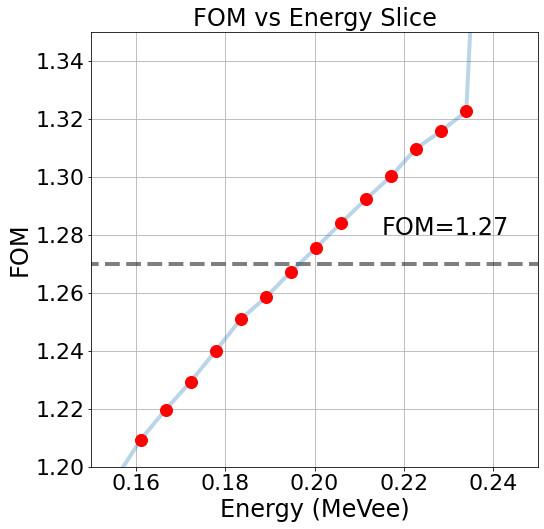

In [18]:
ylim = 1.2, 1.35  # Plot view limits on Y axis
xlim = 0.15, 0.25  # Plot view limits on X axis

fig, ax = plt.subplots(figsize=(8,8))


ax.hlines(1.27, 0, 1.25, color='k', linestyle='--', alpha=0.5, lw=4)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "-",
    alpha=0.3,
    lw=4
)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "ro",
    markersize=12,
)

ax.text(*(0.215, 1.27 + 0.01), "FOM=1.27", fontsize=fontsize)

ax.set_ylim(*ylim)
ax.set_xlim(*xlim)
ax.set_title("FOM vs Energy Slice", fontsize=fontsize)
ax.set_ylabel("FOM", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

# ax.legend(fontsize=fontsize)
ax.grid()
# ax.set_yticks(np.arange(1,2.25,0.25))
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [19]:
# Interpolate between slices near FOM threshold to find best lower energy cutoff
fom_idx = slice_idx

fom_fit = interp1d(df["fom"][fom_idx-1:fom_idx+1], xe[fom_idx-1:fom_idx+1], kind="linear")
L0 = fom_fit(1.27)
f"FOM ENERGY CUTOFF = {L0:.4f} MeVee"

'FOM ENERGY CUTOFF = 0.1966 MeVee'

# Counting Windows

In [20]:
# Window fitting function definition

window_adj_offset = 0

def classify(
    psd_report: pd.DataFrame, 
    lb_fit_fn: Callable[[np.ndarray], np.ndarray], 
    ub_fit_fn: Callable[[np.ndarray], np.ndarray], 
    label: str, 
    le_cutoff: float = L0
) -> pd.DataFrame:
    """Classify signals as neutron or non-neutron for a given count window
    Classification creates a new column of boolean values, where True indicates a neutron classified signal.
    
    Parameters
    ----------
    psd_report: DataFrame
        DataFrame containing signal PSD data. 
        It must have the "tail / total" (for PSD value) and "CALIB_ENERGY" (for calibrated energy) columns.
    lb_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's lower bounds
    ub_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's upper bounds
    label: str
        column label to use for signal classification results
    le_cutoff: float, default L0 (previously determined lower energy cutoff)
        Lower energy cutoff (AKA the left boundary of the neutron window)
        
    Returns
    -------
    psd_report: DataFrame
        Original DataFrame with new column for neutron classification
    """
    psd_report[label] = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)) + 
        window_adj_offset, ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    ) & (psd_report["CALIB_ENERGY"] >= le_cutoff)
    
    return psd_report

def plot_classification(
    neutrons: pd.DataFrame, 
    gammas: pd.DataFrame, 
    lb_fit: Callable[[float], float],
    ub_fit: Callable[[float], float],
    max_energy: float,
    FOM_cutoff: float,
    n_neutrons: int,
    label_n: str = "Neutrons",
    label_g: str = "Non-Neutrons",
) -> tuple[plt.Figure, plt.Axes]:
    """Plot detected events, showing neutron classification window
    The classification window's upper and lower PSD bound functions, as well as the energy cutoff (left side) bound,
    are shown as dotted lines. Points are color labelled to show neutron vs. non-neutron events.
    
    Parameters
    ----------
    neutrons: pd.DataFrame
        DataFrame of neutron classified events to display
    gammas: pd.DataFrame
        DataFrame of non-neutron classified events to display (assumed to be gamma rays)
    lb_fit, ub_fit: Callabl[[float], float]
        Lower and upper PSD bound functions
    max_energy: float
        maximum energy used in this plot (which determines x-axis range)
    FOM_cutoff: float
        energy cutoff, i.e. lowest energy where FOM > 1.27
    n_neutrons: int
        Actual total number of neutrons (to be displayed in title)
        This parameter is used rather than obtained from the neutrons DataFrame
        to allow data samples to be plotted for faster plotting.
    label_n: str
        Series label for neutron classified events
    label_g: str
        Series label for non-neutron classified events (AKA gamma rays)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for neutron classification plot
    ax: plt.Axes
        plot axes for neutron classification plot
    
    """
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label=label_g)
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label=label_n)

    energy_space = np.linspace(xe[0], max_energy + 0.5, 200)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'r', ls="--")

    ax.set_title(f"Counts = {n_neutrons}", fontsize=fontsize)
    ax.set_ylim(0, 0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

In [21]:
# Define variable for all slice indexes to use
# (can be overridden if you only want to plot a subset of x axis)

all_slice_xs = xe[:end_scan_idx]

## NASA  


This classification window is based on the technique outlined in _Fast Neutron Spectroscopy With Organic Scintillation Detectors in a High-Radiation Environment_, Baramsai _et al_.

We define the lower PSD bound as N standard deviations above the gamma mean. We find these points for each slice, then use smoothing and interpolation to generate a lower bound function.

The upper bound for the window is generated by adding a fixed offset to the lower bound value (found to be 0.2 based on observation of the paper's graphs).

As in all windows, the FOM cutoff is used as the left-most bound.

In [22]:
# Define lower and upper bounds (neutron_lb_fit, neutron_ub_fit)

window_offset = 0.2
sigma = 5

neutron_lb = savgol_filter(df["mu1"] + sigma * df["sigma1"], window_length=21, polyorder=3)  # reduce noise
neutron_lb_fit = interp1d(
    all_slice_xs, 
    neutron_lb, 
    fill_value=(neutron_lb[0], neutron_lb[-1]), 
    bounds_error=False)  # now it's a function!

def neutron_ub_fit(x):
    # upper bound is just a fixed PSD offset from lower bound
    # as observed in NASA paper graphs
    return neutron_lb_fit(x) + window_offset

In [23]:
# Plot upper and lower bounds (diagnostic)

# plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
# plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [24]:
# Classify neutrons under NASA window
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, "NASA",le_cutoff=L0)

In [25]:
# Recreate graph sample with classification data
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'Counts = 42246'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

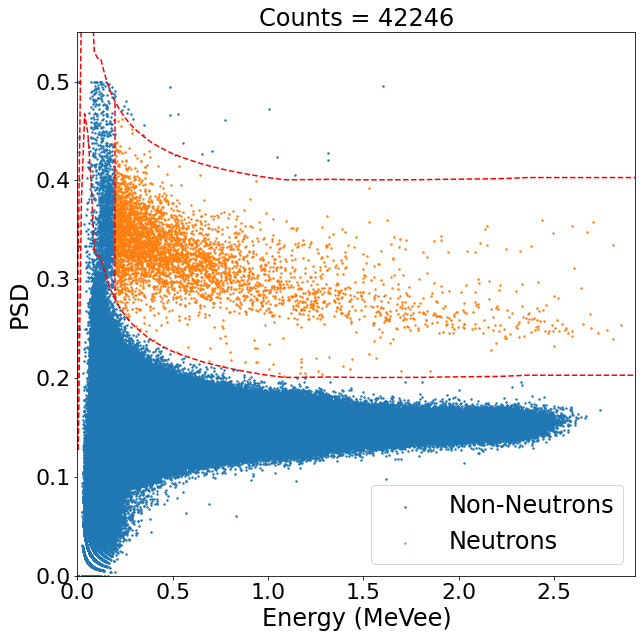

In [26]:
# Plotting NASA classification
plot_classification(
    graph_sample[graph_sample["NASA"]], 
    graph_sample[~graph_sample["NASA"]], 
    neutron_lb_fit, 
    neutron_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["NASA"]].shape[0]
)


# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

## Straight Edge

This classification window is based on the filtering system of the CAEN digitizer, which filters neutron signals based on simple lower and upper PSD and energy thresholds.

We define the lower PSD threshold by generating a point for each slice that is N standard deviations below the neutron mean. These points are then linearly fit, and the intercept with the FOM threshold energy is used as the lower PSD threshold value.

We set the upper PSD threshold to be 0.5.

As in all windows, the FOM cutoff is used as the left-most bound.

In [27]:
# Generate lower bound fit function
straight_edge_sigma = 4

slice_start = fom_idx
neutron_straight_lb = df["mu2"][slice_start:] - straight_edge_sigma * df["sigma2"][slice_start:]
neutron_straight_lb_fit = linregress(all_slice_xs[slice_start:], neutron_straight_lb)

In [28]:
# Display lower bound to be used
f"Lower PSD Cutoff = {neutron_straight_lb_fit.intercept:.4f}"

'Lower PSD Cutoff = 0.2152'

In [29]:
# Define lower and upper bound functions to be used in classification/plotting

def straight_lb(x):
    return neutron_straight_lb_fit.intercept * np.ones_like(x)

def straight_ub(x):
    return 0.5 * np.ones_like(x)

In [30]:
# Classify neutrons under Straight Edge window
psd_report = classify(psd_report, straight_lb, straight_ub, "straight", le_cutoff=L0+0.2)

In [31]:
# Recreate graph sample with classification data
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'Counts = 24242'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

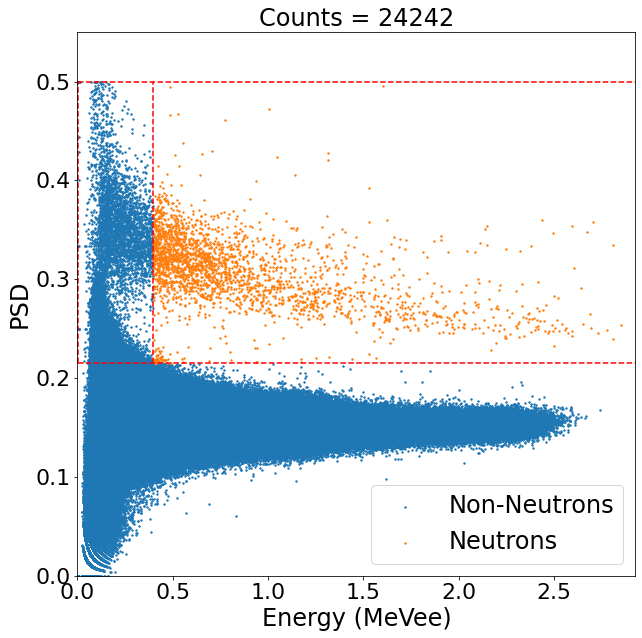

In [32]:
# Plotting Straight Edge classification
plot_classification(
    graph_sample[graph_sample["straight"]], 
    graph_sample[~graph_sample["straight"]], 
    straight_lb, 
    straight_ub, 
    psd_report["CALIB_ENERGY"].max(), 
    L0+0.2,
    psd_report[psd_report["straight"]].shape[0],
    label_n="Neutrons",
    label_g="Non-Neutrons"
)

# CPS

In [33]:
# Defining count rate functions

def counts_over_time_histogram(
    timetags: pd.Series, 
    dwell_time: int, 
    total_time: int
) -> tuple[np.ndarray, np.ndarray]:
    """Generates histogram of event counts per dwell time bin
    Due to limitations of data acquisition, the first bin is ignored, as it gives inaccurately low values.
    
    Parameters
    ----------
    timetags: pd.Series
        timetags for all relevant events 
    dwell_time: int
        time period used for histogram bin width in seconds
    total_time: int
        total data acquisition time in seconds
        
    Returns
    -------
    counts: np.ndarray
        array of counts per bin
    bins: np.ndarray
        bin boundaries (as time in seconds)
    """
    if total_time % dwell_time == 0:
        total_time += 0.001
    input_bins = np.arange(0, total_time, dwell_time)
    counts, bins = np.histogram(timetags, input_bins)
    return counts[1:], bins[1:]


def plot_histogram(
    bins: list[np.ndarray], 
    counts: list[np.ndarray],
    labels: list[str],
    style: Literal['points', 'stairs'] = "points",
    **kwargs
) -> tuple[plt.Figure, plt.Axes]:
    """Plot a set of histograms in one figure
    
    Parameters
    ----------
    bins: list[np.ndarray]
        list of histogram bins to use
    counts: list[np.ndarray]
        list of histogram counts to use
        Each list element must correspond to the element in the same position in `bins`
    labels: list[str]
        list of labels to use
        Each list element must correspond to the element in the same position in `bins`
    style: Literal['points', 'stairs'], default "points"
        plotting style
        The 'points' option creates a scatterplot, while 'stairs' creates a stair plot.
    kwargs
        Other formatting options used in the Matplotlib Axes.plot() or Axes.stairs() functions (as appropriate)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for histogram plot
    ax: plt.Axes
        plot axes for histogram plot
    
    """
    fig, ax = plt.subplots(dpi=140)
    
    for bin, count, label in zip(bins, counts, labels):
        if style == "points":
            ax.plot(bin[:-1], count, "o", label=label, **kwargs)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4, **kwargs)
    
    ax.legend()
    return fig, ax

In [34]:
# Display total time
total_time = psd_report["TIMETAG"].max() * 1e-12 # s
f"Total time = {total_time:.3f}s"

'Total time = 270005.196s'

## NASA Classification Window

In [35]:
# Define dwell time
dwell_time = 60*5 # s

In [36]:
# Generate counts per dwell time

neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["NASA"]]["TIMETAG"] * 1e-12/3600, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["NASA"]]["TIMETAG"]  * 1e-12/3600, dwell_time, total_time
)

In [37]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

In [38]:
# Determine count rate mean and standard deviation (2 methods)
# 1. SD = Square root of total count / total time
# 2. SD determined over set of count rate values

total_count = psd_report.query("NASA == True").shape[0]
neutron_mean = np.average(neutron_time_cps)
neutron_count_sigma = np.sqrt(total_count)/total_time
neutron_cps_sigma = stat.stdev(neutron_time_cps)
print(f"Mean Count Rate: {neutron_mean} 1/s\nSigma (over all dwell rates): {neutron_cps_sigma} 1/s")
print(f"Count Rate Standard Deviation (using total count): {neutron_count_sigma} 1/s")

Mean Count Rate: 0.15649981460882462 1/s
Sigma (over all dwell rates): 0.02447689482587589 1/s
Count Rate Standard Deviation (using total count): 0.0007612383789547222 1/s


Text(0.5, 0, 'Time (hrs)')

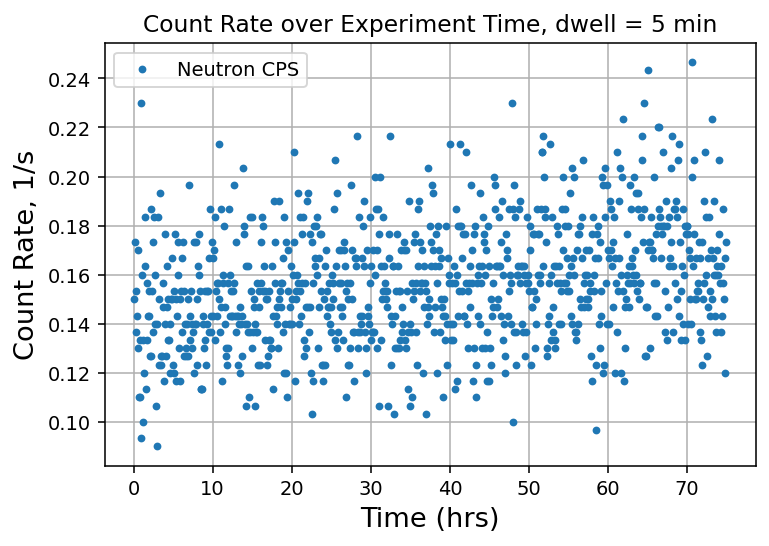

In [39]:
# Plot neutron count rate over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins],#, gamma_time_bins],
    [neutron_time_cps],#, gamma_time_cps],
    labels=["Neutron CPS", "Non-Neutron CPS"],
    markersize =3,
)



#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, dwell = 5 min")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

Text(0.5, 0, 'Time (hrs)')

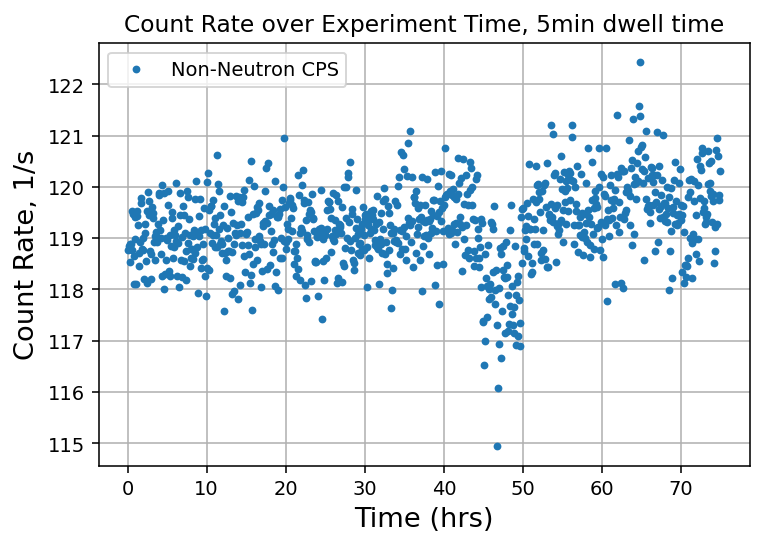

In [40]:
# Plot non-neutron (gamma ray) count rate over experiment run time
fig, ax = plot_histogram(
    [gamma_time_bins],
    [gamma_time_cps],
    labels=["Non-Neutron CPS"],
    markersize=3,
)

#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, 5min dwell time")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

In [41]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 450

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f} 1/s"

'CPS Bin Width: 0.0167 1/s'

(0.075, 0.25)

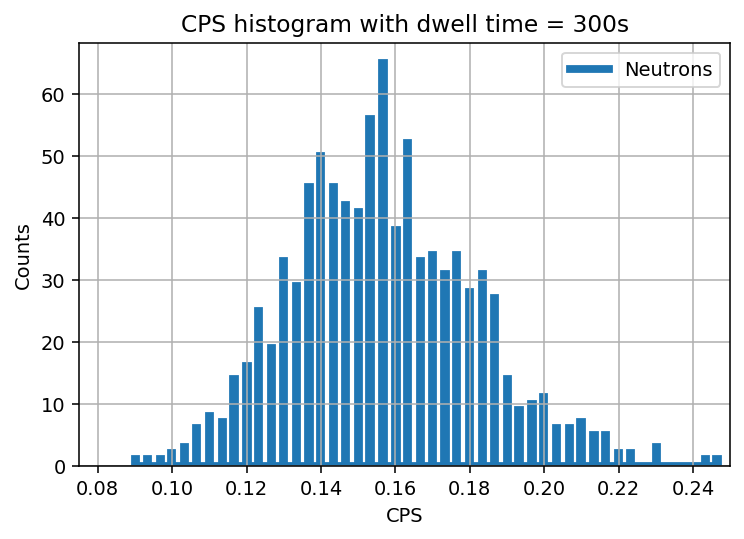

In [42]:
# Plot count rate histogram for neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons"]
)


ax.grid()
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell time = {dwell_time}s")
ax.set_xlim(0.075, 0.25)

## Straight Edge

In [43]:
# Define dwell time
dwell_time = 1 #s

In [44]:
# Generate counts per dwell time
neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["straight"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["straight"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

In [45]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

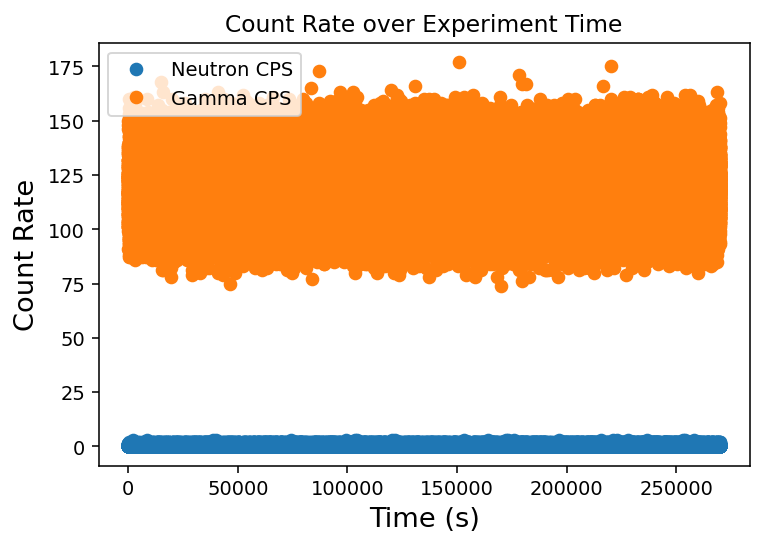

In [46]:
# Plot count rates over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [47]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 0.8306s'

Text(0.5, 1.0, 'CPS histogram with dwell Time = 1s')

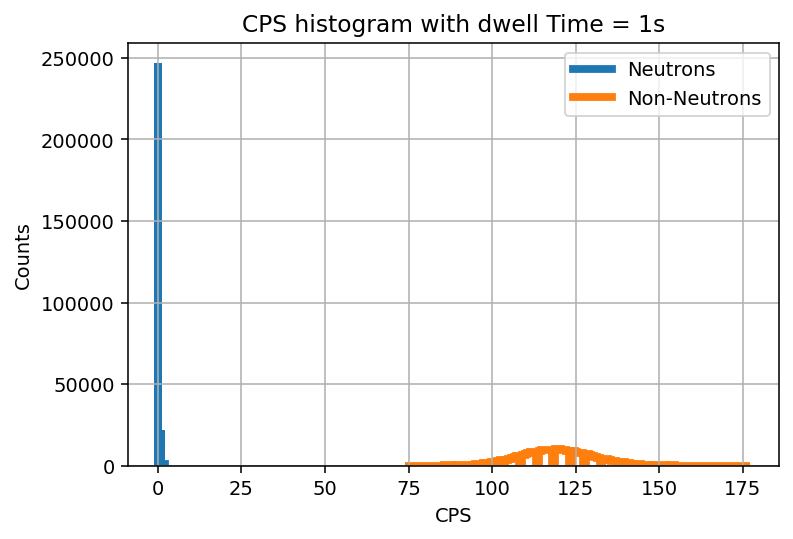

In [48]:
# Plot count rate histogram for neutrons and non-neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Non-Neutrons"]
)


ax.grid()
# ax.set_ylim(0, 40)
# ax.set_xlim(100, 300)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time = {dwell_time}s")